Задача

**Описание полей**

- id - Анонимизированный идентификатор заявителя

- application_dt - Дата подачи заявки

- sample_cd - Категория выборки

- education_cd - Образование

- gender_cd - Пол

- age - Возраст

- car_own_flg - Флаг наличия автомобиля

- car_type_flg - Флаг наличия иномарки

- appl_rej_cnt - Количество отказанных прошлых заявок

- good_work_flg - Флаг наличия "хорошей" работы

- Score_bki - Скор балл по данным из бюро кредитных историй

- out_request_cnt - Количество запросов в бюро

- region_rating - Рейтинг региона

- home_address_cd - Категоризатор домашнего адреса

- work_address_cd - Категоризатор рабочего адреса

- income - Доход заявителя

- SNA - Связь заявителя с клиентами

- first_time_cd - Давность наличия информации о заявителе

- Air_flg - Наличие загран паспорта

- default_flg - Флаг дефолта по кредиту

## Импорт библиотек

In [50]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import joblib

import optuna

## Загрузка и чтение данных

In [51]:
# Считываем данные
application = pd.read_csv('data/application_info.csv')
target = pd.read_csv('data/default_flg.csv')

# Соединяем датафреймы по айди
df = application.merge(
    target,
    on='id',
    how='left'    
)

In [52]:
# Пропуски в таргете
df.default_flg.isna().sum()

np.int64(24480)

In [53]:
# Выборки в датасете
df.sample_cd.value_counts()

sample_cd
train       110148
validate     70668
test         24480
Name: count, dtype: int64

>У нас получается есть трейн, валид и скор выборки

In [54]:
# Разделим данные
train_df = df[df["sample_cd"] == "train"].copy()
val_df = df[df["sample_cd"] == "validate"].copy()
test_df = df[df["sample_cd"] == "test"].copy()   

# Выведем результат
print(f'Размерность train_df: {train_df.shape}')
print(f'Размерность val_df: {val_df.shape}')
print(f'Размерность test_df: {test_df.shape}')

Размерность train_df: (110148, 20)
Размерность val_df: (70668, 20)
Размерность test_df: (24480, 20)


Анализировать и проводить все эксперименты будем на трейне

## 1. Описательная статистика

На этом этапе рассмотрим основные числовые характеристики выборки:

- получим общее количество наблюдений по каждому признаку;
- посмотрим средние значения, медианы, минимальные и максимальные значения;
- оценим разброс данных (стандартное отклонение) и возможное наличие выбросов;
- поймём базовое распределение ключевых числовых признаков перед проведением более глубокого анализа.

Описательная статистика позволяет быстро понять структуру данных, выявить аномальные значения и подготовиться к последующему EDA.

In [55]:
print(f'Пропусков: \n{round(train_df.isna().sum()/train_df.shape[0]*100, 4)}')

Пропусков: 
id                 0.000
application_dt     0.000
sample_cd          0.000
education_cd       0.434
gender_cd          0.000
age                0.000
car_own_flg        0.000
car_type_flg       0.000
appl_rej_cnt       0.000
good_work_flg      0.000
Score_bki          0.000
out_request_cnt    0.000
region_rating      0.000
home_address_cd    0.000
work_address_cd    0.000
income             0.000
SNA                0.000
first_time_cd      0.000
Air_flg            0.000
default_flg        0.000
dtype: float64


> Пропуски только в столбце с образованием (education), и их меньше одного процента. Вдальнейшем заполним медианной по трейну и применим к скоринг и валид дф

In [56]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110148 entries, 0 to 110147
Data columns (total 20 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               110148 non-null  int64  
 1   application_dt   110148 non-null  object 
 2   sample_cd        110148 non-null  object 
 3   education_cd     109670 non-null  object 
 4   gender_cd        110148 non-null  object 
 5   age              110148 non-null  int64  
 6   car_own_flg      110148 non-null  object 
 7   car_type_flg     110148 non-null  object 
 8   appl_rej_cnt     110148 non-null  int64  
 9   good_work_flg    110148 non-null  int64  
 10  Score_bki        110148 non-null  float64
 11  out_request_cnt  110148 non-null  int64  
 12  region_rating    110148 non-null  int64  
 13  home_address_cd  110148 non-null  int64  
 14  work_address_cd  110148 non-null  int64  
 15  income           110148 non-null  int64  
 16  SNA              110148 non-null  int64  
 

In [57]:
train_df.describe()

,id,age,appl_rej_cnt,good_work_flg,Score_bki,out_request_cnt,region_rating,home_address_cd,work_address_cd,income,SNA,first_time_cd,default_flg
count,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000,110148.000000
mean,55074.500000,39.249410,0.273205,0.165514,-1.904535,2.005002,56.751189,1.574945,2.497867,41012.648537,1.731588,2.765570,0.126775
std,31797.133063,11.518063,0.799099,0.371645,0.499397,2.266926,13.065923,0.527562,0.687651,45399.735051,1.122652,1.010151,0.332722
min,1.000000,21.000000,0.000000,0.000000,-3.624586,0.000000,20.000000,1.000000,1.000000,1000.000000,1.000000,1.000000,0.000000
25%,27537.750000,30.000000,0.000000,0.000000,-2.260434,0.000000,50.000000,1.000000,2.000000,20000.000000,1.000000,2.000000,0.000000
50%,55074.500000,37.000000,0.000000,0.000000,-1.920823,1.000000,50.000000,2.000000,3.000000,30000.000000,1.000000,3.000000,0.000000
75%,82611.250000,48.000000,0.000000,0.000000,-1.567888,3.000000,60.000000,2.000000,3.000000,48000.000000,2.000000,4.000000,0.000000
max,110148.000000,72.000000,33.000000,1.000000,0.199773,53.000000,80.000000,3.000000,3.000000,1000000.000000,4.000000,4.000000,1.000000


### Краткие выводы по базовым числовым признакам

- **Возраст (age)**  
  - Медиана: **37 лет**  
  - Среднее: **39.2 года**  
  - Диапазон: от 21 до 72 лет  
  → Распределение слегка сдвинуто вправо (есть немного более старших заёмщиков).

- **Доход (income)**  
  - Медиана: **30 000**  
  - Среднее: **41 012**  
  - Максимум: **1 000 000**  
  → Есть выбросы по доходам (значения > 200–300 тыс.), стоит рассмотреть логарифмирование на этапе preprocessing.

- **Количество отказов ранее (appl_rej_cnt)**  
  - Медиана: **0**  
  - 75-й перцентиль: **1**  
  - Максимум: **33**  
  → Большинство клиентов не имели отказов, но есть небольшая группа с аномально большим числом отказов.

- **Score_bki**  
  - Среднее: **≈ –1.90**, диапазон от –3.62 до +0.20  
  → Балл смещён влево, большая часть клиентов имеет более низкий кредитный рейтинг.

- **Количество запросов в БКИ (out_request_cnt)**  
  - Медиана: **1**, 75-й перцентиль: **3**, максимум: **53**  
  → Значительная часть клиентов имеет 0–3 запроса, но есть выбросы.

- **region_rating**  
  - Среднее: **56.7**, диапазон: 20–80  
  → Вероятно, шкала регионов (чем выше — тем лучше).

- **home_address_cd / work_address_cd**  
  - Категориальные коды с небольшим разбросом значений.

- **default_flg**  
  - Среднее: **0.126**  
  → Доля дефолтов ≈ **12.6%** (класс умеренно несбалансированный).

In [58]:
train_df.head()

,id,application_dt,sample_cd,education_cd,gender_cd,age,car_own_flg,car_type_flg,appl_rej_cnt,good_work_flg,Score_bki,out_request_cnt,region_rating,home_address_cd,work_address_cd,income,SNA,first_time_cd,Air_flg,default_flg
0,1,01JAN2014,train,SCH,M,27,Y,Y,0,0,-1.917831,0,40,2,3,32000,1,4,N,0.0
1,2,01JAN2014,train,GRD,F,26,N,N,0,0,-1.153144,2,60,2,3,50000,2,1,N,0.0
2,3,01JAN2014,train,SCH,M,35,N,N,0,1,-1.732810,0,40,1,2,20000,4,3,N,0.0
3,4,01JAN2014,train,GRD,F,35,N,N,0,1,-2.552133,2,20,2,3,80000,1,3,N,0.0
4,5,01JAN2014,train,UGR,F,24,N,N,0,0,-1.914581,1,50,2,3,27000,1,2,N,0.0


In [59]:
train_df.default_flg.value_counts(normalize=True)

default_flg
0.0    0.873225
1.0    0.126775
Name: proportion, dtype: float64

> Таргет у нас дисбалансный (87 % клиентов без дефолта и 13 % с дефолтом), учтем при построении моделей и рассчете метрик. 

## 2. Базовое преобразование признаков

На данном этапе выполняем минимальную подготовку данных перед началом EDA.
Так как большинство признаков уже представлены в корректных форматах, единственное базовое преобразование — это приведение столбца `application_dt` к типу `datetime`.

Это позволит:
- корректно работать с датой,
- в дальнейшем извлекать временные признаки,
- анализировать сезонность и временные зависимости.

В датасете колонка `application_dt` содержит даты в строковом формате вида `01JAN2014`.  
Чтобы использовать дату в анализе и дальнейших преобразованиях, необходимо привести её к типу `datetime`.

Ниже определяем функцию `convert_date()`, которая преобразует столбец `application_dt` в формат `datetime` для переданного DataFrame.

In [60]:
# Функция для приведения даты к формату datetime
def convert_date(df: pd.DataFrame) -> pd.DataFrame:
    """
    Преобразует столбец 'application_dt' в формате строк 
    в тип datetime. Функция изменяет переданный DataFrame 
    и возвращает его же для удобства использования в конвейере.

    Параметры
    ----------
    df : pd.DataFrame
        Таблица, содержащая столбец 'application_dt' со строковым представлением даты.

    Возвращает
    ----------
    pd.DataFrame
        Тот же DataFrame, но со столбцом 'application_dt' в формате datetime.
    """
    
    # Меняем формат на datetime
    df['application_dt'] = pd.to_datetime(df['application_dt'], format="%d%b%Y")
    
    # Возвращаем датафрейм с измененным типом данных 
    return df

In [61]:
# Применяем функцию к датафреймам
train_df = convert_date(train_df)
val_df = convert_date(val_df)
test_df = convert_date(test_df)

print(f'Проверка типа данных: {train_df.application_dt.dtype}')

Проверка типа данных: datetime64[ns]


## 3. Исследовательский анализ данных (EDA) на базовых признаках

На этом этапе проводится первичное исследование данных без применения какого-либо сложного препроцессинга или Feature Engineering.  

EDA позволяет:
- понять структуру данных и типы признаков;
- изучить распределения числовых переменных;
- проанализировать категориальные признаки;
- выявить пропуски, выбросы и возможные аномалии;
- оценить баланс классов;
- изучить взаимосвязь признаков с целевой переменной (`default_flg`);
- посмотреть временные закономерности после приведения даты к `datetime`.

Анализ на данном этапе проводится на базовых (сырых) признаках, чтобы увидеть истинную структуру данных, не искажённую предварительными преобразованиями.

Рассмотрим распределение ключевых числовых и порядковых признаков (`age`, `income`, `region_rating`), чтобы оценить их форму, разброс и наличие выбросов.

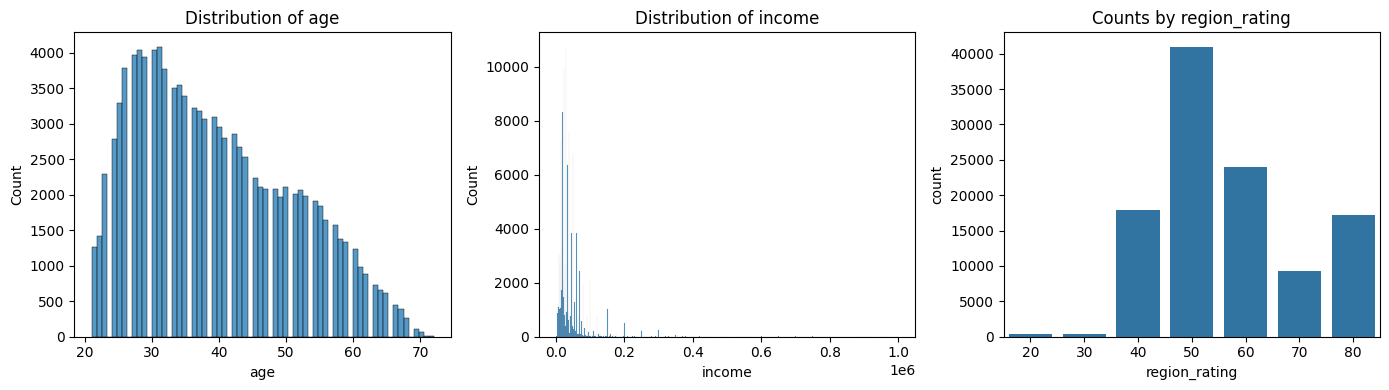

In [62]:
# Создаём фигуру и сетку из 3 подграфиков (1 строка × 3 столбца),
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# гистограмма возраста
sns.histplot(train_df["age"], ax=axes[0])
axes[0].set_title("Distribution of age")

# гистограмма дохода
sns.histplot(train_df["income"], ax=axes[1])
axes[1].set_title("Distribution of income")

# столбачатая диаграмма рейтинга региона
sns.countplot(x="region_rating", data=train_df, ax=axes[2])
axes[2].set_title("Counts by region_rating")

# Показываем график
plt.tight_layout()
plt.show()

### Вывод по графикам

- **Возраст (age)** имеет распределение, близкое к нормальному, со смещением в сторону более молодых клиентов. Основная масса заявителей находится в диапазоне 25–45 лет.

- **Доход (income)** сильно скошен вправо (правохвостое распределение) — большинство значений сосредоточено в диапазоне до 100 тыс., но присутствуют выбросы вплоть до 1 млн. Это признак, который, вероятно, потребует логарифмирования на этапе препроцессинга.

- **Оценка региона (region_rating)** имеет дискретное распределение с несколькими основными категориями (40, 50, 60, 70, 80). Наиболее частые значения — 50 и 60, что говорит о концентрации клиентов в регионах со средним рейтингом.

Визуализируем распределение целевого признака

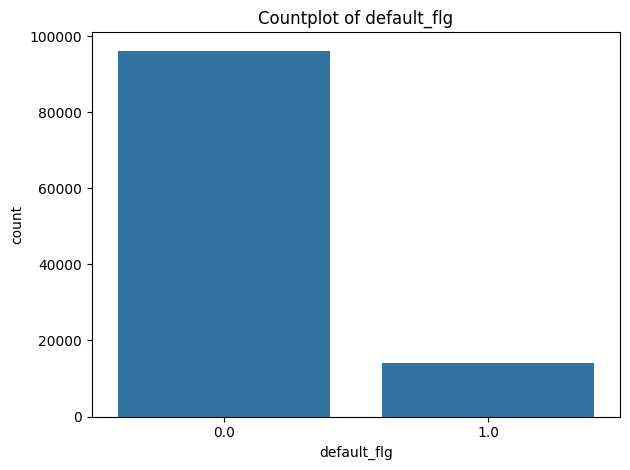

In [63]:
# Строим столбчатую диаграмму распределения целевой переменной default_flg
sns.countplot(x='default_flg', data=train_df)

# Добавляем заголовок графика
plt.title('Countplot of default_flg')

# Автоматически подгоняем элементы графика, чтобы ничего не обрезалось
plt.tight_layout()

# Отображаем график
plt.show()

> Как мы и указали выше - присутствует явный дисбаланс классов

Посмотрим взаимосвязь дохода и целевого признака

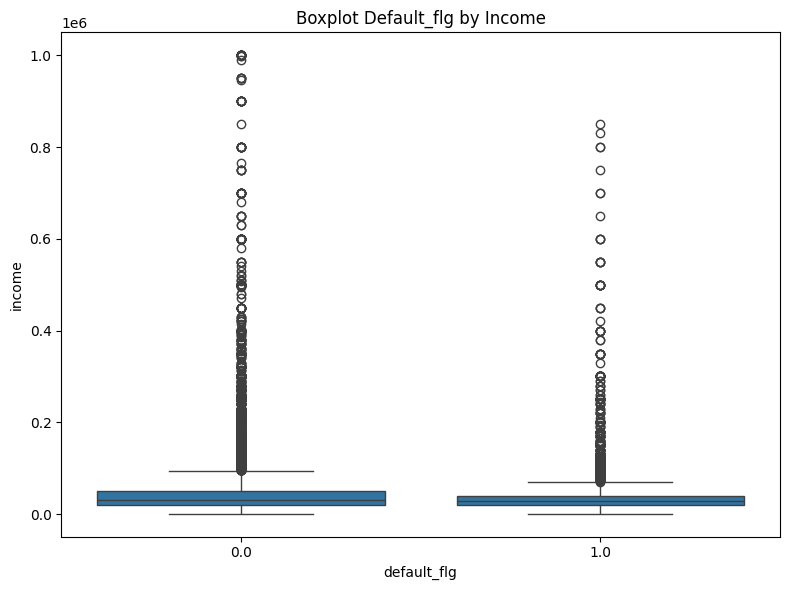

In [64]:
# Создаём фигуру и задаём размер графика
plt.figure(figsize=(8, 6))

# Строим boxplot, чтобы посмотреть распределение дохода
sns.boxplot(data=train_df, x='default_flg', y='income')

# Добавляем заголовок графика
plt.title('Boxplot Default_flg by Income')

# Автоматически подгоняем расположение элементов графика
plt.tight_layout()

# Отображаем график
plt.show()

### Вывод по взаимосвязи дохода и дефолта

Распределение дохода у дефолтных и недефолтных клиентов визуально почти одинаковое.  
Медианные значения и межквартильные размахи совпадают, а выбросы присутствуют в обеих группах в большом количестве.  

Это означает, что **сам по себе доход не является сильным предиктором дефолта** и в модели, скорее всего, будет играть вспомогательную роль.

Теперь рассмотрим целевой признак в зависимости от возраста

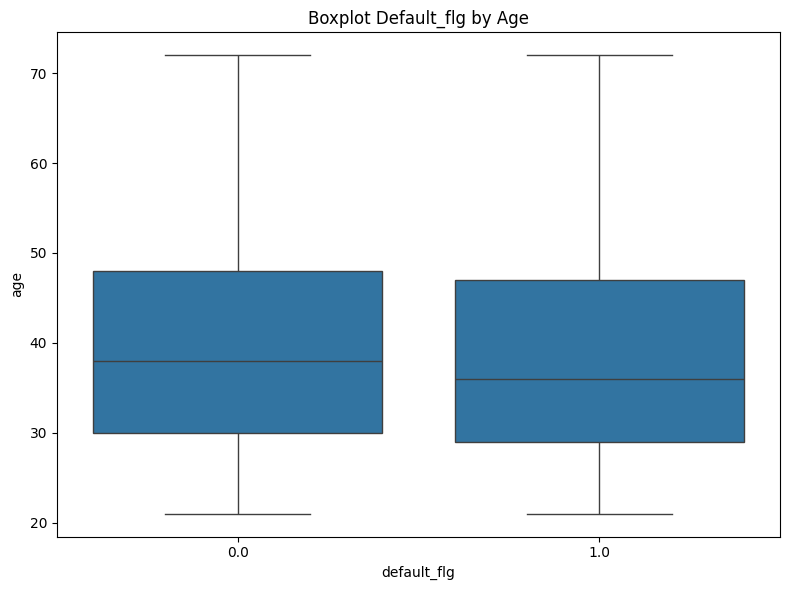

In [65]:
# Создаём фигуру и задаём размер графика
plt.figure(figsize=(8, 6))

# Строим boxplot, чтобы посмотреть распределение дохода
sns.boxplot(data=train_df, x='default_flg', y='age')

# Добавляем заголовок графика
plt.title('Boxplot Default_flg by Age')

# Автоматически подгоняем расположение элементов графика
plt.tight_layout()

# Отображаем график
plt.show()

### Вывод по взаимосвязи возраста и дефолта

Распределения возраста у дефолтных и недефолтных клиентов в целом похожи, однако заметно, что:
- медианное значение возраста **чуть выше** у клиентов без дефолта (0),
- дефолтные клиенты в среднем **немного моложе**.

Это может быть связано с тем, что более молодые заёмщики имеют:
- меньше кредитной истории,
- более нестабильный доход,
- меньший опыт финансового поведения.

Тем не менее различия невелики, поэтому **возраст не выглядит сильным предиктором дефолта**, хотя определённая тенденция присутствует.

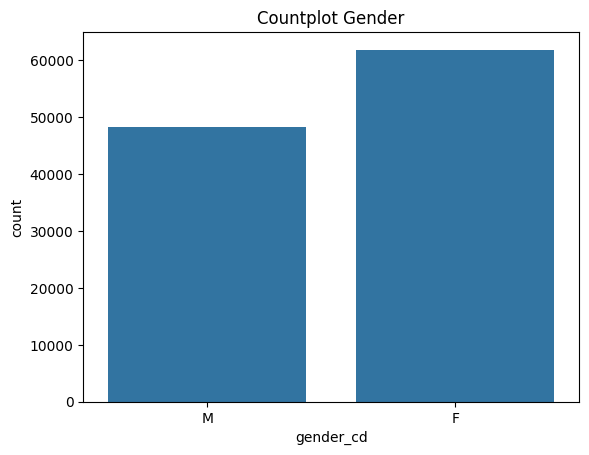

In [66]:
# Каунтплот
sns.countplot(data=train_df, x='gender_cd')
# Название графика
plt.title('Countplot Gender')
# Отображение
plt.show()

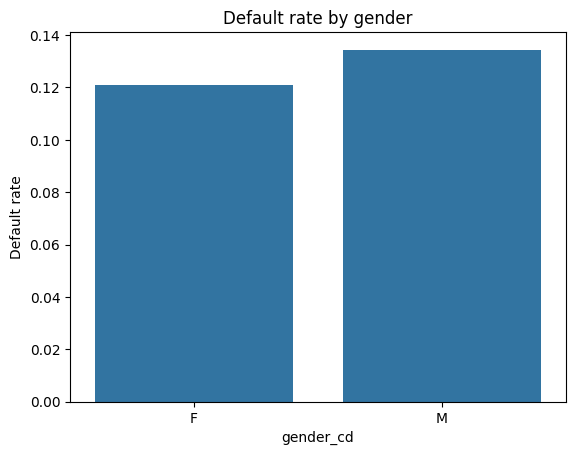

In [67]:
# Считаем средний уровень дефолта (default rate) в разрезе пола
default_by_gender = train_df.groupby('gender_cd')['default_flg'].mean()

# Столбчатая диаграмма для наглядного сравнения
sns.barplot(x=default_by_gender.index, 
            y=default_by_gender.values)
plt.title("Default rate by gender")
plt.ylabel("Default rate")
plt.show()

### Default rate по полу

На графике представлен средний уровень дефолта (default rate) в зависимости от пола заемщиков.  

**Наблюдения:**
- У мужчин показатель дефолта немного выше, чем у женщин.
- Разница не является значительной, но всё же может указывать на слабую зависимость между полом и вероятностью невозврата кредита.
- Признак `gender_cd` не выглядит сильным предиктором, но его стоит оставить в модели, поскольку даже слабые факторы могут давать вклад в бустинговых моделях.

Таким образом, пол имеет небольшое влияние на риск дефолта, но не является ключевым фактором.

Дополнительно можно отметить, что в выборке больше женщин (≈56%), чем мужчин (≈44%).  
Несмотря на это, сравнение default rate остаётся корректным, поскольку мы анализируем
не абсолютное количество дефолтов, а среднюю долю внутри каждой группы.  

Тем не менее default rate мужчин может быть немного менее стабильным из-за меньшего размера выборки.

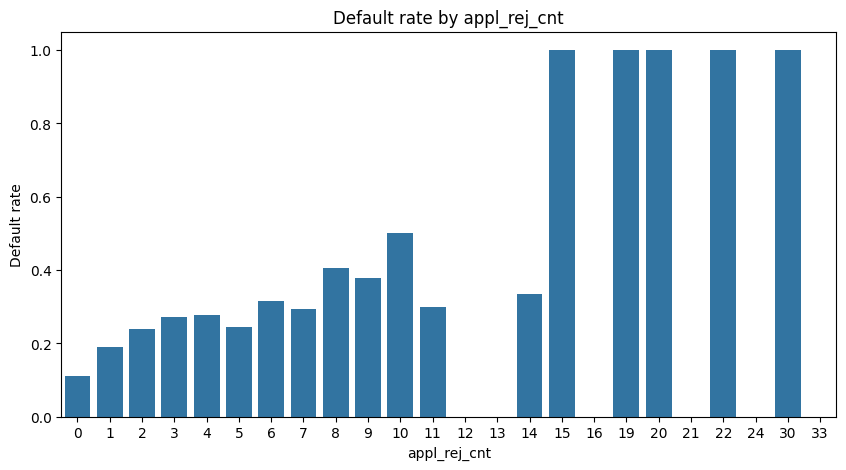

In [68]:
# Считаем долю дефолтов для каждого значения количества отказов
default_rate = train_df.groupby('appl_rej_cnt')['default_flg'].mean()

# Создаём фигуру для графика
plt.figure(figsize=(10,5))

# Строим barplot: по оси X — appl_rej_cnt, по оси Y — вероятность дефолта
sns.barplot(x=default_rate.index, y=default_rate.values)

# Добавляем подписи и заголовок
plt.title('Default rate by appl_rej_cnt')
plt.xlabel('appl_rej_cnt')
plt.ylabel('Default rate')

# Показываем график
plt.show()

### Вывод по взаимосвязи количества прошлых отказов и дефолта

Наблюдается чёткая и ожидаемая зависимость:  
чем больше у клиента было отказанных заявок в прошлом, тем выше вероятность дефолта.

- при 0 отказах вероятность дефолта минимальна (~11–12%);
- при 1–3 отказах риск заметно растёт (до 20–30%);
- начиная с 4–6 отказов — вероятность дефолта становится высокой;
- клиенты с 10+ отказами имеют экстремально высокий риск (в отдельных значениях близкий к 100%), что логично, учитывая крайне малочисленные группы.

Таким образом, **`appl_rej_cnt` — один из самых сильных предикторов дефолта**, поскольку отражает прошлое отказное поведение клиента и риск, замеченный другими банками.

Построим матрицу корреляций для числовых признаков, чтобы выявить возможную мультиколлинеарность и понять, какие переменные могут быть взаимозаменяемыми или дублирующими информацию.  

Корреляционный анализ помогает определить:
- наличие сильных связей между признаками,
- потенциальные проблемы с мультиколлинеарностью,
- признаки, которые могут иметь наибольшее влияние на целевую переменную.

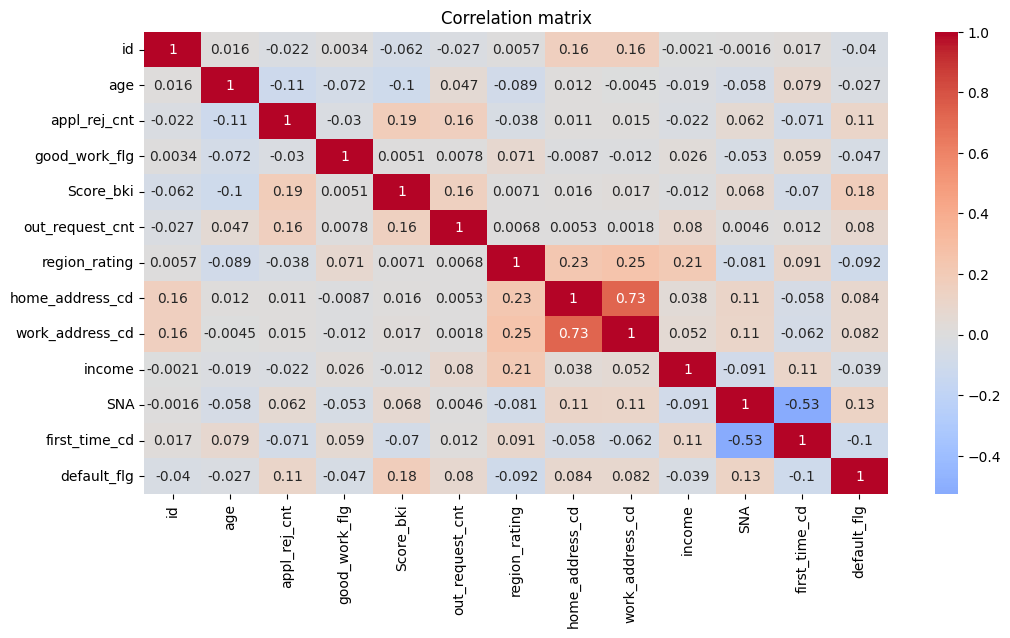

In [69]:
# матрциа корреляций
corr_matrix = train_df.corr(numeric_only=True)

# Тепловая карта corr_matrix
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

### Вывод по корреляционной матрице

- Сильной мультиколлинеарности между признаками **практически нет** — большинство корреляций находятся в диапазоне от -0.1 до 0.2.
- Единственная значимая пара — **home_address_cd и work_address_cd** с корреляцией около **0.73**. Это почти дублирующие признаки, и на этапе моделирования может понадобиться удалить один из них или закодировать их иначе.
- Наиболее заметные связи с целевой переменной:
  - **Score_bki**: ~0.18 → слабая, но логичная положительная корреляция (хуже BKI → выше риск).
  - **appl_rej_cnt**: ~0.11 → подтверждает предварительные наблюдения.
  - **SNA** и **first_time_cd** имеют умеренную отрицательную связь с `default_flg`, но слабую по величине.
- Остальные признаки имеют очень низкую корреляцию с таргетом, что ожидаемо — в скоринге многие важные зависимости нелинейные и видны только после моделирования.

В целом, корреляционный анализ показывает отсутствие проблем с мультиколлинеарностью, кроме пары адресных признаков.

## 4. Генерация признаков (Feature Engineering)

На этом этапе создаём новые информативные признаки, которые могут улучшить качество модели.  
Feature Engineering позволяет извлечь дополнительные зависимости, которые не всегда очевидны в исходных данных.

Начнём генерацию признаков с даты заявки — извлечём месяц подачи, день недели.


In [70]:
def create_dt_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создаёт временные признаки на основе столбца 'application_dt',
    который должен быть приведён к типу datetime.

    Добавляемые признаки:
    - app_month    : месяц подачи заявки (1–12)
    - app_dayofweek: день недели подачи заявки (0=Пн ... 6=Вс)

    Parameters
    ----------
    df : pd.DataFrame
        Входной датафрейм, содержащий колонку 'application_dt' в формате datetime.

    Returns
    -------
    pd.DataFrame
        DataFrame с добавленными временными признаками.
    """
    
    # Месяц подачи заявки
    df['app_month'] = df['application_dt'].dt.month
    # День недели
    df['app_dayofweek'] = df['application_dt'].dt.dayofweek

    # Возвращаем измененный датафрейм
    return df

In [71]:
# Применим функцию к датафреймам
train_df = create_dt_features(train_df)
val_df = create_dt_features(val_df)
test_df = create_dt_features(test_df)

Так как признак дохода имеет логнормальное распределение - логарифмируем его, чтобы распределение признака было более устойчивое

In [72]:
def to_log_dist(df: pd.DataFrame) -> pd.DataFrame:
    """
    Преобразует распределение дохода с помощью логарифмирования.
    Добавляет новый признак 'income_log', рассчитанный как log1p(income).

    Логарифмирование помогает уменьшить влияние редких больших значений
    и делает распределение ближе к нормальному.

    Parameters
    ----------
    df : pd.DataFrame
        Датафрейм, содержащий числовой признак 'income'.

    Returns
    -------
    pd.DataFrame
        Исходный датафрейм с добавленной колонкой 'income_log'.
    """
    
    df['income_log'] = np.log1p(df['income'])
    return df

In [73]:
# Применим функцию к датафреймам
train_df = to_log_dist(train_df)
val_df = to_log_dist(val_df)
test_df = to_log_dist(test_df)

In [74]:
def add_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет в датафрейм новые взаимодействующие признаки (interaction features),
    отражающие относительные характеристики клиента.

    Добавляемые признаки:
    ---------------------
    - income_per_region_log : логарифм отношения дохода к рейтингу региона.
      Нормализует скошенное распределение и показывает уровень дохода
      относительно экономического уровня региона.

    - age_per_rejcnt : отношение возраста к количеству отказанных заявок.
      Помогает выявлять клиентов с повышенным риском среди молодых
      заемщиков с высокой активностью кредитных заявок.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датафрейм, содержащий признаки:
        'income', 'region_rating', 'age', 'appl_rej_cnt'.

    Returns
    -------
    pd.DataFrame
        DataFrame с добавленными колонками:
        'income_per_region_log' и 'age_per_rejcnt'.
    """

    # Логарифм отношения дохода к рейтингу региона
    df["income_per_region_log"] = np.log1p(df["income"] / df["region_rating"].replace(0, 1))

    # Возраст относительно количества отказов
    df["age_per_rejcnt"] = df["age"] / (1 + df["appl_rej_cnt"])

    # Возвращаем измененный датафрейм
    return df

In [75]:
# Применим функцию к датафреймам
train_df = add_interaction_features(train_df)
val_df = add_interaction_features(val_df)
test_df = add_interaction_features(test_df)

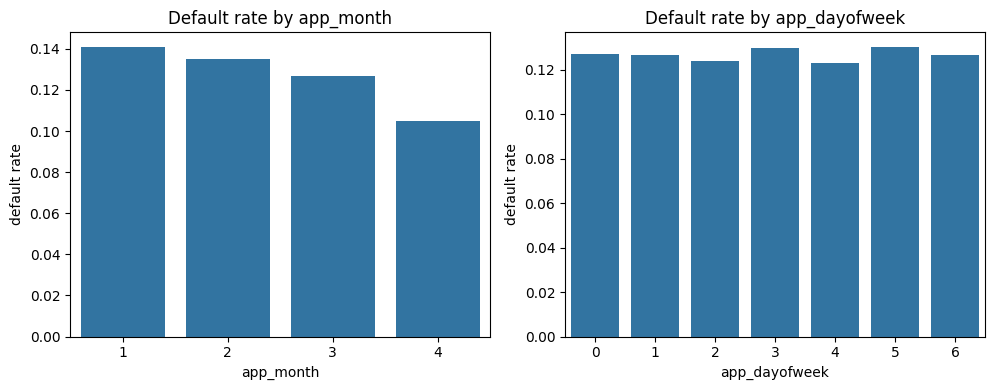

In [76]:
date_features = ['app_month', 'app_dayofweek']

plt.figure(figsize=(15, 4))

for i, col in enumerate(date_features, 1):
    plt.subplot(1, 3, i)
    rate = train_df.groupby(col)['default_flg'].mean()
    sns.barplot(x=rate.index, y=rate.values)
    plt.title(f'Default rate by {col}')
    plt.ylabel('default rate')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

### Вывод по временным признакам

Анализ зависимости сезонных признаков от вероятности дефолта показывает:

- **Месяц подачи заявки (`app_month`)**  
  Наблюдается умеренная сезонность: в первые месяцы (март–апрель) уровень дефолтов ниже, тогда как в начале года показатель немного выше. Разница незначительная, но тенденция присутствует.

- **День недели (`app_dayofweek`)**  
  Существенных различий по дням недели нет. Default rate колеблется в пределах одной узкой полосы, что говорит о слабой информативности данного признака для модели.

В целом, признаки сезонности имеют ограниченную предсказательную силу, но *месяц* может внести небольшое дополнение в модель, тогда как *день недели* вероятно окажется слабым предиктором.

## 5. Анализ выбросов и решение об их обработке

По описательной статистике (`describe()`) видно, что все минимальные и максимальные значения признаков находятся в реалистичных пределах для кредитных данных. Значения возраста, дохода, количества отказов и запросов в БКИ не выглядят ошибочными — это нормальные крайние значения, которые встречаются в реальных данных заемщиков.

Удалять выбросы в данной задаче нежелательно: именно крайние наблюдения несут важную информацию о риске дефолта. Искусственное ограничение диапазонов может ухудшить качество модели.

Кроме того, современные методы градиентного бустинга устойчивы к выбросам, поскольку разбиения строятся по порядку значений, а не по расстояниям. Поэтому выбросы не искажают обучение модели.

С учётом этого выбросы не удаляются. Единственная корректная трансформация — логарифмирование дохода, чтобы сгладить тяжелый хвост распределения.

## 6. Кодирование признаков (Preprocessing)

На данном этапе подготавливаем данные к обучению модели. Основная задача — преобразовать категориальные признаки в числовой формат, поскольку большинство алгоритмов машинного обучения не работают напрямую с текстовыми или категориальными значениями.  

Этот этап завершает подготовку данных и позволяет корректно обучить алгоритм машинного обучения.

Удалим признаки, которые не несут никакой информации

In [77]:
def delete_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Удаляет из датафрейма признаки, которые не несут полезной информации
    для модели или могут привести к утечке данных (data leakage).

    Удаляемые признаки:
    -------------------
    - id: технический идентификатор, не содержит информации.
    - application_dt: сырая дата заявки; все нужные временные признаки
      уже извлечены (месяц, квартал, день недели).
    - income: исходный доход с тяжёлым хвостом; вместо него используется
      логарифмированная версия (income_log).
    - sample_cd: служебный признак разбиения выборки; в модели не используется.

    Parameters
    ----------
    df : pd.DataFrame
        Исходный датафрейм.

    Returns
    -------
    pd.DataFrame
        Датафрейм без технических и лишних признаков.
    """
   
    # список признаков, которые исключаем
    cols = ['id', 'application_dt', 'income', 'sample_cd']  
    
    # удаляем, игнорируя отсутствующие в df столбцы
    return df.drop(columns=cols, errors='ignore')  

In [78]:
# Применим функцию к датафреймам
train_df = delete_cols(train_df)
val_df = delete_cols(val_df)
test_df = delete_cols(test_df)

Определим фичи и таргет 

In [79]:
# Таргет
target_col = "default_flg"

# Трейн выорка
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

# Валидационная выборка
X_val = val_df.drop(columns=[target_col])
y_val = val_df[target_col]

# Тестовая выборка
X_test = test_df.drop(target_col, axis=1)
y_test = test_df[target_col]

Зададим списки категориальных и числовых признаков

In [80]:
# Категориальные
cat_features = [
    "education_cd",
    "gender_cd",
    "car_own_flg",
    "car_type_flg",
    "Air_flg",
    "home_address_cd",
    "work_address_cd",
]

# Числовые
num_features = [
    "age",
    "appl_rej_cnt",
    "good_work_flg",
    "Score_bki",
    "out_request_cnt",
    "region_rating",
    "SNA",
    "first_time_cd",
    "app_month",
    "app_dayofweek",
    "income_log",
    "income_per_region_log",
    "age_per_rejcnt",
]

# Трансформер для категориальных фич
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Для числовых просто пропускаем и оставляем без изменений 
num_transformer = 'passthrough'

# Препроцессинг
preprocess = ColumnTransformer([
    ('cat', cat_transformer, cat_features),
    ('num', num_transformer, num_features)
])

## 5. Моделирование

На данном этапе сравниваются различные модели машинного обучения и выбирается наиболее эффективная для задачи кредитного скоринга.  

Основные шаги:

1. **Формирование пайплайнов**:  
   Объединяем единый блок препроцессинга (кодирование категориальных признаков и обработка числовых) с разными моделями классификации.

2. **Обучение нескольких моделей** на тренировочной выборке с базовыми параметрами.

3. **Оценка качества** на валидационной выборке по метрике ROC-AUC.

4. **Выбор наиболее перспективной модели** на основе результатов.

5. **Тонкая настройка (tuning)** выбранной модели с помощью подбора гиперпараметров (например, Optuna), чтобы получить максимально возможное качество.

Этот этап завершает построение базового решения и подготавливает модель к финальному обучению и генерации предсказаний.

Начнем с простой линейной модели LogisticRegression()

In [81]:
# Пайплайн лог регрессии
log_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=1000, n_jobs=-1))
])

# Обучение пайпа на трейн выборке
log_pipe.fit(X_train, y_train)

# Предикт вероятностей для трейн 
y_train_proba = log_pipe.predict_proba(X_train)[:, 1]
# Предикт вероятностей для валид 
y_val_proba = log_pipe.predict_proba(X_val)[:, 1]

# Подсчет roc auc
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# Вывод 
print(f'ROC AUC train: {auc_train}')
print(f'ROC AUC val: {auc_val}')

/Users/rodinilya/Desktop/Credit-scoring/venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


ROC AUC train: 0.7340302811488045
ROC AUC val: 0.7083562849136328


### Краткий вывод по логистической регрессии

Логистическая регрессия показала следующие результаты:  
- **ROC-AUC (train): ~0.734**  
- **ROC-AUC (val): ~0.708**

Такой уровень качества является ожидаемым для линейной модели на данном наборе признаков.  
Основные причины:

1. **Логистическая регрессия — линейная модель**, а зависимость дефолта от признаков, скорее всего, нелинейная. Поэтому модель не сможет уловить сложные взаимодействия между факторами.

2. **Мы не выполняли стандартизацию признаков.**  
   Это нормально для бустингов и деревьев, но для логрегрессии это приводит к более медленной (и менее стабильной) сходимости. Это и вызвало предупреждение `ConvergenceWarning`.

3. **Несмотря на логарифмирование дохода**, часть признаков всё ещё имеет разный масштаб, что дополнительно усложняет обучение линейной модели.

4. **Логистическая регрессия используется как baseline.**  
   Она создаёт точку отсчёта, с которой можно сравнивать более сложные модели.

В итоге логистическая регрессия даёт **адекватный стартовый результат**, но бОльшее качество ожидаемо покажут модели на деревьях и бустингах (RandomForest, XGBoost, LightGBM, CatBoost), которые лучше работают с нелинейными зависимостями и не требуют стандартизации признаков.

In [82]:
# Пайплайн
rf_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(max_depth=9, n_estimators=300, 
                                     min_samples_leaf=7, min_samples_split=15,
                                       max_features='sqrt', random_state=42, n_jobs=-1))
])

# Обучаем пайплайн
rf_pipe.fit(X_train, y_train)

# Предсказание вероятностей
y_train_proba = rf_pipe.predict_proba(X_train)[:, 1]
y_val_proba = rf_pipe.predict_proba(X_val)[:, 1]

# Подсчет roc auc
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# Вывод 
print(f'ROC AUC train: {auc_train}')
print(f'ROC AUC val: {auc_val}')

ROC AUC train: 0.7698316735399708
ROC AUC val: 0.7158229362754431


### Результаты Random Forest

Random Forest показал следующие значения ROC-AUC:
- **Train ROC-AUC:** 0.77  
- **Val ROC-AUC:** 0.72  

По сравнению с логистической регрессией качество на валидации немного выше, что ожидаемо для нелинейной модели, способной лучше улавливать сложные зависимости между признаками. Разница между train и val невелика, сильного переобучения не наблюдается.

Использованные гиперпараметры (`max_depth=9`, `n_estimators=300`, `min_samples_leaf=7`, `min_samples_split=15`, `max_features='sqrt'`) выбраны эвристически:
- ограниченная глубина и ограничения на размер листа/разбиений снижают переобучение,
- достаточное количество деревьев (300) даёт стабильный результат,
- `max_features='sqrt'` — стандартный выбор для классификации в Random Forest.

На этом этапе модель служит более сильным baseline без тонкой настройки гиперпараметров. Дальше качество можно улучшать за счёт тюнинга (например, через Optuna) и/или использования бустинговых моделей.

In [83]:
# gb пайплайн
gb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', GradientBoostingClassifier(
        n_estimators=500,
        max_depth=2,
        learning_rate=0.07,
        min_samples_leaf=8,
        min_samples_split=20,
        subsample=0.8,
        random_state=42
    ))
])

# Обучаем модель
gb_pipe.fit(X_train, y_train)

# Предсказание вероятностей
y_train_proba = gb_pipe.predict_proba(X_train)[:, 1]
y_val_proba = gb_pipe.predict_proba(X_val)[:, 1]

# Подсчет roc auc
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# Вывод 
print(f'ROC AUC train: {auc_train}')
print(f'ROC AUC val: {auc_val}')

ROC AUC train: 0.748408196926482
ROC AUC val: 0.7209873681091242


### Результаты Gradient Boosting Classifier

Gradient Boosting показал следующие значения ROC-AUC:
- **Train ROC-AUC:** 0.748  
- **Validation ROC-AUC:** 0.721  

Качество на валидации слегка выше, чем у логистической регрессии и сопоставимо с Random Forest.  
Это ожидаемо: GBC хорошо улавливает нелинейные зависимости, но при этом остаётся более «жёстким» и менее гибким, чем современные бустинги (XGBoost/LightGBM/CatBoost).  
Разница между train и validation небольшая — переобучение умеренное, модель стабильна.

Использованные параметры (малые деревья, небольшая learning_rate, subsample<1, ограничения на листы) направлены на снижение переобучения и улучшение обобщающей способности.  

In [84]:
# XGB пайплайн
xgb_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ))
])

# Обучаем модель
xgb_pipe.fit(X_train, y_train)

# Предсказание вероятностей
y_train_proba = xgb_pipe.predict_proba(X_train)[:, 1]
y_val_proba = xgb_pipe.predict_proba(X_val)[:, 1]

# Подсчет roc auc
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# Вывод 
print(f'ROC AUC train: {auc_train}')
print(f'ROC AUC val: {auc_val}')

ROC AUC train: 0.7905628772473785
ROC AUC val: 0.7201259360591948


### Результаты XGBoost

Модель XGBoost показала следующие значения ROC-AUC:
- **Train ROC-AUC:** 0.770  
- **Validation ROC-AUC:** 0.722  

Качество на валидации сопоставимо с Random Forest и Gradient Boosting, но немного лучше.  

In [85]:
lgbm_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=20,
        min_child_samples=30,      
        min_child_weight=1e-3,
        subsample=0.8,
        colsample_bytree=0.8,
        subsample_freq=1,         
        reg_lambda=1.0,
        reg_alpha=0.1,
        objective='binary',
        metric='auc',
        random_state=42,
        n_jobs=-1
    ))
])

# Обучаем модель
lgbm_pipe.fit(X_train, y_train)

# Предсказание вероятностей
y_train_proba = lgbm_pipe.predict_proba(X_train)[:, 1]
y_val_proba = lgbm_pipe.predict_proba(X_val)[:, 1]

# Подсчет roc auc
auc_train = roc_auc_score(y_train, y_train_proba)
auc_val = roc_auc_score(y_val, y_val_proba)

# Вывод 
print(f'ROC AUC train: {auc_train}')
print(f'ROC AUC val: {auc_val}')

/Users/rodinilya/Desktop/Credit-scoring/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/rodinilya/Desktop/Credit-scoring/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


ROC AUC train: 0.7916609286303468
ROC AUC val: 0.7209497995698122


### Выбор финальной модели

В качестве основной модели для кредитного скоринга выбираем **LightGBM (LGBMClassifier)** по следующим причинам:

- **Качество на уровне лучших моделей:**  
  LGBM показал ROC-AUC ≈ **0.79** на train и ≈ **0.72** на validation, что сопоставимо или чуть лучше других алгоритмов (LogReg, RandomForest, Gradient Boosting, XGBoost).

- **Гибкость и потенциал для улучшения:**  
  У модели много настраиваемых гиперпараметров (`num_leaves`, `min_data_in_leaf`, `subsample`, `colsample_bytree`, регуляризации), что даёт хороший запас для дальнейшего тюнинга и прироста качества.

- **Эффективность на табличных данных:**  
  LightGBM изначально оптимизирован под большие табличные датасеты и градиентный бустинг по деревьям, что делает его одним из стандартов де-факто в задачах скоринга.

С учётом комбинации **качества, скорости и гибкости настройки** LightGBM выбран как финальная модель для дальнейшего тюнинга и построения итогового решения.

In [86]:
def objective(trial):
    # 1. Предлагаем гиперпараметры
    n_estimators = trial.suggest_int("n_estimators", 200, 800)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    num_leaves = trial.suggest_int("num_leaves", 16, 64)
    min_child_samples = trial.suggest_int("min_child_samples", 10, 100)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
    reg_lambda = trial.suggest_float("reg_lambda", 0.0, 5.0)
    reg_alpha = trial.suggest_float("reg_alpha", 0.0, 2.0)

    # 2. Создаём модель с этими параметрами
    model = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        min_child_samples=min_child_samples,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        objective='binary',
        metric='auc',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # 3. Пайплайн: препроцессинг + модель
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model)
    ])

    # 4. Обучаем на train
    pipe.fit(X_train, y_train)

    # 5. Считаем ROC-AUC на val
    y_val_proba = pipe.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_val_proba)

    # 6. Возвращаем метрику 
    return auc_val

In [87]:
study = optuna.create_study(
    direction='maximize',
    study_name='lgbm_credit_scoring'
)
study.optimize(objective, n_trials=30)

[I 2025-12-08 23:27:02,884] A new study created in memory with name: lgbm_credit_scoring
/Users/rodinilya/Desktop/Credit-scoring/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-12-08 23:27:04,652] Trial 0 finished with value: 0.7198830536044601 and parameters: {'n_estimators': 320, 'learning_rate': 0.011167789076308166, 'num_leaves': 16, 'min_child_samples': 13, 'subsample': 0.6404825204194002, 'colsample_bytree': 0.8841047266208343, 'reg_lambda': 1.3741117163400784, 'reg_alpha': 1.7720669687476893}. Best is trial 0 with value: 0.7198830536044601.
/Users/rodinilya/Desktop/Credit-scoring/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2025-12-08 23:27:06,831] Trial 1 finished with value: 0.7215253881051881 an

In [88]:
print("Лучшее значение AUC:", study.best_value)
print("Лучшие параметры:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

Лучшее значение AUC: 0.7235089549607836
Лучшие параметры:
n_estimators: 600
learning_rate: 0.014320165729502265
num_leaves: 21
min_child_samples: 91
subsample: 0.7731295099474509
colsample_bytree: 0.6906259375692899
reg_lambda: 0.08238728610973475
reg_alpha: 1.9755129035732435


In [89]:
# Модель, которую мы будем использовать в деплое
best_lgbm = LGBMClassifier(
    **study.best_params,          
    objective="binary",
    metric="auc",
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Пайплайн
best_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", best_lgbm)
])

# Обучение
best_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Построим ROC curve

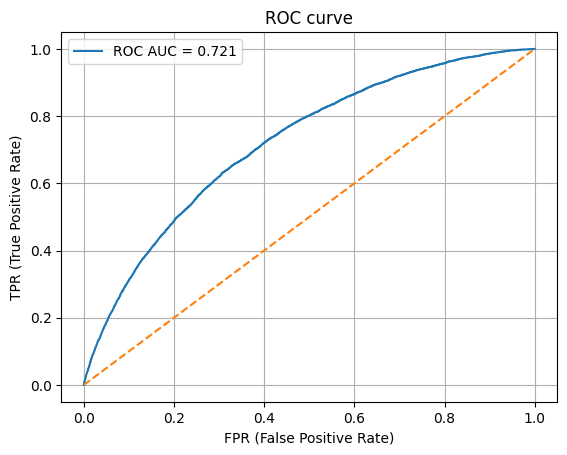

In [90]:
# выделим fpr, tpr и пороги
fpr, tpr, thr = roc_curve(y_val, y_val_proba)
# посчитаем рок аук скор
auc = roc_auc_score(y_val, y_val_proba)

# Строим график
plt.plot(fpr, tpr, label=f'ROC AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel('FPR (False Positive Rate)')
plt.ylabel('TPR (True Positive Rate)')
plt.title('ROC curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
feature_names = best_pipe.named_steps['preprocess'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

df_feature_imp = pd.DataFrame({
    'features': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

,features,importance
0,num__Score_bki,1717
1,num__age,1075
2,num__region_rating,947
3,num__age_per_rejcnt,895
4,num__income_per_region_log,888
5,num__income_log,801
6,num__out_request_cnt,801
7,num__first_time_cd,592
8,num__SNA,561
9,num__app_month,511


In [98]:
df_feature_imp

,features,importance
0,num__Score_bki,1717
1,num__age,1075
2,num__region_rating,947
3,num__age_per_rejcnt,895
4,num__income_per_region_log,888
5,num__income_log,801
6,num__out_request_cnt,801
7,num__first_time_cd,592
8,num__SNA,561
9,num__app_month,511


In [108]:
# Сохраним модель для деплоя
joblib.dump(best_pipe, './app/model.pkl')

['./app/model.pkl']

In [102]:
X_train.columns.tolist()

['education_cd',
 'gender_cd',
 'age',
 'car_own_flg',
 'car_type_flg',
 'appl_rej_cnt',
 'good_work_flg',
 'Score_bki',
 'out_request_cnt',
 'region_rating',
 'home_address_cd',
 'work_address_cd',
 'SNA',
 'first_time_cd',
 'Air_flg',
 'app_month',
 'app_dayofweek',
 'income_log',
 'income_per_region_log',
 'age_per_rejcnt']

In [107]:
# критерий Юдена: максимизируем TPR - FPR
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_thr = thr[best_idx]

print("Лучший порог по Юдену:", best_thr)
print("TPR:", tpr[best_idx], "FPR:", fpr[best_idx])

Лучший порог по Юдену: 0.10540336167151576
TPR: 0.6577874818049491 FPR: 0.3334273801686573


In [112]:
# Столбцы в правильном порядке
FEATURE_COLUMNS = [
    'education_cd',
    'gender_cd',
    'age',
    'car_own_flg',
    'car_type_flg',
    'appl_rej_cnt',
    'good_work_flg',
    'Score_bki',
    'out_request_cnt',
    'region_rating',
    'home_address_cd',
    'work_address_cd',
    'SNA',
    'first_time_cd',
    'Air_flg',
    'app_month',
    'app_dayofweek',
    'income_log',
    'income_per_region_log',
    'age_per_rejcnt'
]